In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
import seaborn as sns
import glob
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, recall_score, precision_score, f1_score
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.preprocessing.image import ImageDataGenerator

In [3]:
opacity_path = r"C:\Users\gnana\COVID-19_Radiography_Dataset\Lung_Opacity\images"

normal_path = r"C:\Users\gnana\COVID-19_Radiography_Dataset\Viral Pneumonia\images"

In [4]:
IMG_SIZE = (150, 150)

BATCH_SIZE = 32

In [5]:
opacity_image = glob.glob(opacity_path + r"\*.*")

print("Number of Opacity image:", len(opacity_image))

normal_image = glob.glob(normal_path + r"\*.*")

print("Number of Normal image:", len(normal_image))

Number of Opacity image: 6012
Number of Normal image: 1345


In [6]:
opacity_df = pd.DataFrame({"Filename": opacity_image,
                        "label" : 1})

normal_df = pd.DataFrame({"Filename" : normal_image,
                         "label" : 0})

df = pd.concat([opacity_df,
                normal_df], ignore_index = True)

In [7]:
print("\n Dataset Shape: ")
print(df.shape)
print("\n First 5 Records: ")
print(df.head())
print("\n Last 5 Records: ")
print(df.tail())
print("\n Missing Value: ")
print(df.isnull().sum())
print("\n Duplicate Records: ")
print(df.duplicated().sum())
df = df.drop_duplicates()



 Dataset Shape: 
(7357, 2)

 First 5 Records: 
                                            Filename  label
0  C:\Users\gnana\COVID-19_Radiography_Dataset\Lu...      1
1  C:\Users\gnana\COVID-19_Radiography_Dataset\Lu...      1
2  C:\Users\gnana\COVID-19_Radiography_Dataset\Lu...      1
3  C:\Users\gnana\COVID-19_Radiography_Dataset\Lu...      1
4  C:\Users\gnana\COVID-19_Radiography_Dataset\Lu...      1

 Last 5 Records: 
                                               Filename  label
7352  C:\Users\gnana\COVID-19_Radiography_Dataset\Vi...      0
7353  C:\Users\gnana\COVID-19_Radiography_Dataset\Vi...      0
7354  C:\Users\gnana\COVID-19_Radiography_Dataset\Vi...      0
7355  C:\Users\gnana\COVID-19_Radiography_Dataset\Vi...      0
7356  C:\Users\gnana\COVID-19_Radiography_Dataset\Vi...      0

 Missing Value: 
Filename    0
label       0
dtype: int64

 Duplicate Records: 
0


In [8]:
print("\n Class Distribution: ")
print(df["label"].value_counts())

print("\n Class Names: ")
print(
    df["label"].value_counts().rename(
        index = {0: "NORMAL", 1: "OPACITY"}
    )
)


 Class Distribution: 
label
1    6012
0    1345
Name: count, dtype: int64

 Class Names: 
label
OPACITY    6012
NORMAL     1345
Name: count, dtype: int64


In [9]:
df = df.sample(frac=1,random_state=42
).reset_index(drop=True)

train_df, test_df = train_test_split(df,
    test_size=0.20,
    random_state=42,
    stratify=df["label"])

print("\nTraining Images:",len(train_df))
print("Testing Images:",len(test_df))


Training Images: 5885
Testing Images: 1472


In [10]:
#IMAGE DATA GENERATOR

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=10,
    zoom_range=0.1,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True,
    validation_split=0.20)

# TEST DATA GENERATOR

test_datagen = ImageDataGenerator(
    rescale=1./255)

#TRAINING DATA GENERATOR

train_generator = train_datagen.flow_from_dataframe(
    train_df,
    x_col="Filename",
    y_col="label",
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="raw",
    subset="training",
    shuffle=True)

#VALIDATION DATA GENERATOR

validation_generator = train_datagen.flow_from_dataframe(
    train_df,
    x_col="Filename",
    y_col="label",
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="raw",
    subset="validation",
    shuffle=False)

# TEST DATA GENERATOR

test_generator = test_datagen.flow_from_dataframe(
    test_df,
    x_col="Filename",
    y_col="label",
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="raw",
    shuffle=False)

Found 4708 validated image filenames.
Found 1177 validated image filenames.
Found 1472 validated image filenames.


In [11]:
print("\nTraining Samples:",train_generator.samples)
print("Validation Samples:",validation_generator.samples)
print("Testing Samples:",test_generator.samples)


Training Samples: 4708
Validation Samples: 1177
Testing Samples: 1472


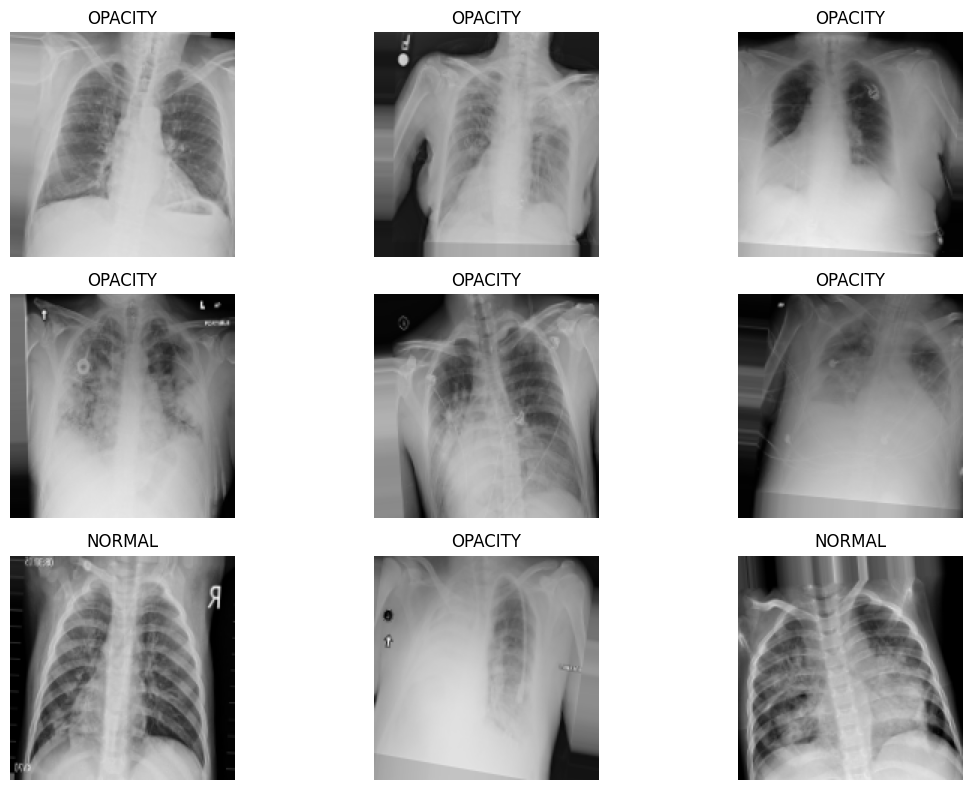

In [12]:
image, labels = next(train_generator)
plt.figure(figsize = (12, 8))

for i in range(9):
    plt.subplot(3, 3, i + 1)
    plt.imshow(image[i])

    if labels[i] == 1:
        plt.title("OPACITY")
    else:
        plt.title("NORMAL")

    plt.axis("off")

plt.tight_layout()
plt.show()

In [13]:
model = Sequential([

    Conv2D(32, (3,3), activation = "relu",
           input_shape = (150, 150, 3)),
    MaxPooling2D((2, 2)),

    Conv2D(64, (3, 3), activation = "relu"),
    MaxPooling2D((2, 2)),

    Conv2D(128, (3, 3), activation = "relu"),
    MaxPooling2D((2, 2)),

    Flatten(),

    Dense(128, activation = "relu"),

    Dropout(0.5),

    Dense(1, activation = "sigmoid") 
])

C:\Users\gnana\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [14]:
model.summary()

model.compile(optimizer = "adam",
              loss = "binary_crossentropy",
              metrics = ["accuracy"]
             )

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 148, 148, 32)        │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 74, 74, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 72, 72, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 36, 36, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ (None, 34, 34, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_2 (MaxPooling2D)       │ (None, 17, 17, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 36992)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 128)                 │       4,735,104 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 1)                   │             129 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 4,828,481 (18.42 MB)

 Trainable params: 4,828,481 (18.42 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
history = model.fit(train_generator,
                   validation_data = validation_generator,
                    epochs = 10
                   )

test_loss, test_accuracy = model.evaluate(test_generator)
print("TEST RESULTS")
print("Test Loss : ", test_loss)
print("Test Acuuracy : ", test_accuracy)

Epoch 1/10
 29/148 ━━━━━━━━━━━━━━━━━━━━ 2:59 2s/step - accuracy: 0.8147 - loss: 0.3935

In [ ]:
plt.figure(figsize = (8, 5))

#Accuracy Plot

plt.plot(history.history["accuracy"],
         label = "Training Accuracy")
plt.plot(history.history["val_accuracy"],
        label = "Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training and Validation Accuracy")
plt.legend()
plt.show()

In [ ]:
plt.figure(figsize = (8, 5))

#Loss Plot

plt.subplot(1, 2, 2)
plt.plot(history.history["loss"], label="Training Loss", color='orange', marker='o')
plt.plot(history.history["val_loss"], label="Validation Loss", color='red', marker='o')
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

In [ ]:
test_generator.reset()
predictions = model.predict(test_generator)

predicted_classes = (predictions >= 0.5).astype(int).flatten()

image_path = opacity_image[0]
print("\nImage Used For Prediction:")
print(image_path)

img = tf.keras.utils.load_img(image_path,
    target_size=IMG_SIZE)


img_array = tf.keras.utils.img_to_array(img)


img_array = np.expand_dims(img_array,axis=0)


img_array = img_array / 255.0


prediction = model.predict(img_array)
probability = prediction[0][0]
print("\nPrediction Probability:",probability)


plt.figure(figsize=(5, 5))
plt.imshow(img)
plt.axis("off")
if probability >= 0.5:
    print("Prediction: PNEUMONIA")
    plt.title("Prediction: PNEUMONIA")
else:
    print("Prediction: NORMAL")
    plt.title("Prediction: NORMAL")
plt.show()